## Tumor Subtype Classification using MOFA factors

In [85]:
import pandas as pd
import numpy as np
import mofax as mfx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

In [86]:
def load_mofa_factors(model_path, clinical_index):
    model = mfx.mofa_model(model_path)
    factors = model.get_factors(df = True)
    factors = factors.loc[clinical_index]
    return factors

In [87]:
mofa_models = {
    "mofa_trained_lg2": "../../data/latent/mofa_trained_lg2.hdf5",
    "mofa_trained_vsn": "../../data/latent/mofa_trained_vsn.hdf5",
    "mofa_trained_lg2_fs": "../../data/latent/mofa_trained_lg2_fs.hdf5",
    "mofa_trained_vsn_fs": "../../data/latent/mofa_trained_vsn_fs.hdf5"
}

In [88]:
clinical_data = pd.read_csv('../../data/cleaned_data/clinical_cleaned.csv', index_col = 0)
y = clinical_data['tumor_subtype'].map({'other_subtype': 1, 'ductal_type': 0})

In [89]:
X = load_mofa_factors(mofa_models['mofa_trained_lg2'], clinical_data.index)

Stratified Split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

#### Training

In [91]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [2, 3, 4, 5],
    'min_samples_leaf': [2, 5, 10],
    'min_samples_split': [5, 10, 15],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [92]:
rf_base_model = RandomForestClassifier(random_state = 42)

GridSearchCV with Stratified 5-Fold Cross Validation

In [93]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
grid_search = GridSearchCV(estimator = rf_base_model, param_grid = param_grid, cv = cv, scoring = 'balanced_accuracy', n_jobs = -1)
grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [5, 10, ...], ...}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


Get the best model

In [94]:
rf_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best hyperparameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
Best CV score: 0.65


Get train and validation scores of best_estimator

In [95]:
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'average_precision': 'average_precision'
}

In [96]:
cv_results = cross_validate(rf_model, X_train, y_train, cv = cv, scoring = scoring, return_train_score = True, n_jobs = -1)

#### Testing

In [97]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # Probability for the 'other_subtype' (class 1)

In [98]:
test_metrics = {
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'PR AUC': average_precision_score(y_test, y_prob)
}

Confusion Matrix

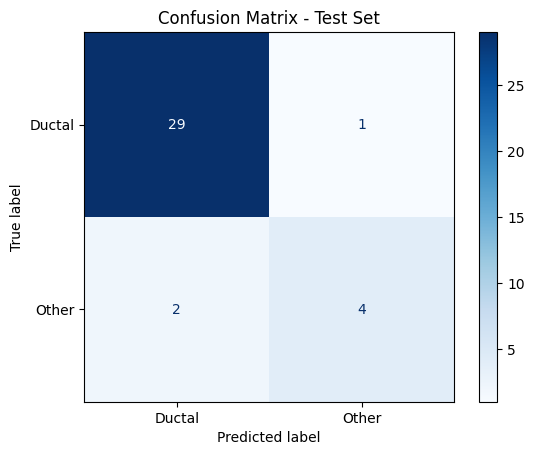

In [99]:
confusion_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=['Ductal', 'Other'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

In [100]:
comparison_df = pd.DataFrame({
    'Metric': ['Balanced Accuracy', 'Precision', 'Recall', 'F1 Score', 'PR AUC'],
    'CV Train (mean ± std)': [
        f"{cv_results['train_balanced_accuracy'].mean():.3f} ± {cv_results['train_balanced_accuracy'].std():.3f}",
        f"{cv_results['train_precision'].mean():.3f} ± {cv_results['train_precision'].std():.3f}",
        f"{cv_results['train_recall'].mean():.3f} ± {cv_results['train_recall'].std():.3f}",
        f"{cv_results['train_f1'].mean():.3f} ± {cv_results['train_f1'].std():.3f}",
        f"{cv_results['train_average_precision'].mean():.3f} ± {cv_results['train_average_precision'].std():.3f}"
    ],
    'CV Validation (mean ± std)': [
        f"{cv_results['test_balanced_accuracy'].mean():.3f} ± {cv_results['test_balanced_accuracy'].std():.3f}",
        f"{cv_results['test_precision'].mean():.3f} ± {cv_results['test_precision'].std():.3f}",
        f"{cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}",
        f"{cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}",
        f"{cv_results['test_average_precision'].mean():.3f} ± {cv_results['test_average_precision'].std():.3f}"
    ],
    'Final Test Set': [
        f"{test_metrics['Balanced Accuracy']:.3f}",
        f"{test_metrics['Precision']:.3f}",
        f"{test_metrics['Recall']:.3f}",
        f"{test_metrics['F1 Score']:.3f}",
        f"{test_metrics['PR AUC']:.3f}"
    ]
})

print("Random Forest Performance Comparison:")
display(comparison_df)

Random Forest Performance Comparison:


,Metric,CV Train (mean ± std),CV Validation (mean ± std),Final Test Set
0,Balanced Accuracy,1.000 ± 0.000,0.650 ± 0.042,0.817
1,Precision,1.000 ± 0.000,1.000 ± 0.000,0.800
2,Recall,1.000 ± 0.000,0.300 ± 0.084,0.667
3,F1 Score,1.000 ± 0.000,0.455 ± 0.098,0.727
4,PR AUC,1.000 ± 0.000,0.421 ± 0.074,0.515
